In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score
from tqdm import tqdm

In [2]:
language="hindi"

corpus_file = f"/mnt/Velocity_Vault/Wiki_Dump/Corpus/{language}_processed.txt"

In [3]:

def load_corpus(corpus_file_path):
    """Load the preprocessed corpus"""
    try:
        with open(corpus_file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        words = text.split()
        return words
    except Exception as e:
        print(f"Error loading corpus: {e}")
        return None


In [4]:

def compute_vocabulary_growth(words, sample_percent=0.05):
    """Compute vocabulary growth curve"""
    total_tokens = len(words)
    step_size = max(1, total_tokens // (len(words)*sample_percent))
    
    corpus_sizes = []
    vocabulary_sizes = []
    vocabulary = set()
    
    for i in tqdm(range(len(words))):
        word = words[i]
        vocabulary.add(word)
        if i % step_size == 0 or i == total_tokens - 1:
            corpus_sizes.append(i + 1)
            vocabulary_sizes.append(len(vocabulary))
    
    return np.array(corpus_sizes), np.array(vocabulary_sizes)


In [5]:
def fit_heaps_law_linear_regression(corpus_sizes, vocabulary_sizes):
    """Fit Heaps' law using linear regression on log-transformed data"""
    # Remove any zero or negative values (shouldn't exist but safe)
    valid_indices = (corpus_sizes > 0) & (vocabulary_sizes > 0)
    corpus_sizes = corpus_sizes[valid_indices]
    vocabulary_sizes = vocabulary_sizes[valid_indices]
    
    # Log-transform the data with safety checks
    log_N = np.log(corpus_sizes)
    log_V = np.log(vocabulary_sizes)
    
    # Remove infinite values (just in case)
    finite_mask = np.isfinite(log_N) & np.isfinite(log_V)
    log_N = log_N[finite_mask]
    log_V = log_V[finite_mask]

    
    model = LinearRegression()
    model.fit(log_N.reshape(-1, 1), log_V)
    
    # Extract parameters
    beta = model.coef_[0]
    log_K = model.intercept_
    K = np.exp(log_K)
    
    # Calculate predictions
    log_pred = model.predict(log_N.reshape(-1, 1))
    predictions = np.exp(log_pred)
    
    # Calculate additional metrics
    r2 = r2_score(vocabulary_sizes, predictions)
    mse = mean_squared_error(vocabulary_sizes, predictions)
    rmse = np.sqrt(mse)
    
    # Calculate confidence intervals (optional but useful)
    residuals = log_V - log_pred
    std_error = np.std(residuals)
    beta_std_error = std_error / np.sqrt(np.sum((log_N - np.mean(log_N))**2))
    
    return {
        'K': K,
        'beta': beta,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'predictions': predictions,
        'model': model,
        'beta_std_error': beta_std_error,
        'confidence_95': (beta - 1.96*beta_std_error, beta + 1.96*beta_std_error)
    }

In [6]:

def plot_heaps_law_fit(corpus_sizes, vocabulary_sizes, results, language):
    """Create plots for Heaps' law fit"""
    fig, (ax2) = plt.subplots(1, figsize=(6, 6))
    
    ax2.plot(corpus_sizes, vocabulary_sizes, 'o', markersize=3, alpha=0.7, label='Actual Data')
    ax2.plot(corpus_sizes, results['predictions'], 'r-', linewidth=2, label='Heaps\' Law Fit')
    
    ax2.set_xlabel('Corpus Size (log scale)')
    ax2.set_ylabel('Vocabulary Size (log scale)')
    ax2.set_title(f'Heaps\' Law - Log-Log Scale\nR² = {results["r2"]:.4f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [7]:

def analyze_heaps_law(corpus_file_path, language):
    """Main analysis function"""
    print(f"Analyzing Heaps' Law for {language}")
    print("=" * 50)
    
    # Load corpus
    words = load_corpus(corpus_file_path)
    if not words:
        return None
    
    # Compute vocabulary growth
    corpus_sizes, vocabulary_sizes = compute_vocabulary_growth(words)
    print(f"Corpus size: {len(words):,} tokens")
    print(f"Final vocabulary: {vocabulary_sizes[-1]:,} words")
    
    # Fit using linear regression on log-transformed data
    results = fit_heaps_law_linear_regression(corpus_sizes, vocabulary_sizes)
    
    # Display results
    print(f"\nHEAPS' LAW FITTING RESULTS (Linear Regression on Log-Transformed Data):")
    print("=" * 70)
    print(f"K parameter: {results['K']:.4f}")
    print(f"β parameter: {results['beta']:.4f}")
    print(f"R² score: {results['r2']:.4f}")
    print(f"MSE: {results['mse']:.4f}")
    print(f"RMSE: {results['rmse']:.4f}")
    
    # Plot results
    plot_heaps_law_fit(corpus_sizes, vocabulary_sizes, results, language)
    
    return results


Analyzing Heaps' Law for hindi


100%|██████████| 88757626/88757626 [00:14<00:00, 6001599.27it/s]


Corpus size: 88,757,626 tokens
Final vocabulary: 868,332 words

HEAPS' LAW FITTING RESULTS (Linear Regression on Log-Transformed Data):
K parameter: 11.0474
β parameter: 0.6093
R² score: 0.9488
MSE: 2093221565.5780
RMSE: 45751.7384


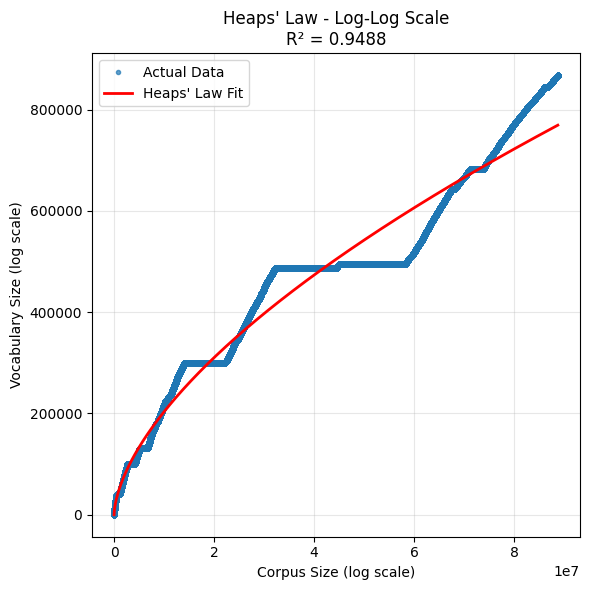

In [8]:
results = analyze_heaps_law(corpus_file, language)